# 미니프로젝트: AI4I 제조 데이터 머신러닝

**데이터셋:** `dataset/day1_miniproject.csv` (AI4I 2020 Predictive Maintenance, 10,000건)

| 태스크 | 타겟 (y) | 입력 (X) | 문제 유형 |
|:---:|:---:|:---|:---:|
| 회귀 | `Torque` | Type, Air/Process temperature, Rotational speed, Tool wear | 연속형 예측 |
| 분류 | `Machine failure` | Type, Air/Process temperature, Rotational speed, Torque, Tool wear | 이진 분류 |

**프로세스:** EDA → 전처리(다중공선성 제거, 인코딩, 스케일링) → CV fold 최적화 → 하이퍼파라미터 튜닝 → Test 평가


## 0) 분석 준비 — 라이브러리 & 데이터 로드


In [1]:
%pip install xgboost lightgbm catboost seaborn matplotlib -q

Note: you may need to restart the kernel to use updated packages.


In [2]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

if not hasattr(np, "long"):
    np.long = np.int_
    np.ulong = np.uint


def setup_korean_font():
    """한글 폰트를 파일 경로로 직접 등록 (가장 안정적)"""
    font_paths = [
        "/System/Library/Fonts/AppleSDGothicNeo.ttc",       # macOS
        "/System/Library/Fonts/Supplemental/AppleGothic.ttf",
        "/Library/Fonts/NanumGothic.ttf",
        "C:/Windows/Fonts/malgun.ttf",                      # Windows
        "/usr/share/fonts/truetype/nanum/NanumGothic.ttf",  # Linux
    ]
    for path in font_paths:
        if os.path.exists(path):
            fm.fontManager.addfont(path)
            prop = fm.FontProperties(fname=path)
            name = prop.get_name()
            print(f"한글 폰트 적용: {name}")
            return name, prop

    # 경로 탐색 실패 시 OS별 이름으로 fallback
    import platform
    if platform.system() == "Darwin":
        fallback_names = ["Apple SD Gothic Neo", "AppleGothic"]
    elif platform.system() == "Windows":
        fallback_names = ["Malgun Gothic", "NanumGothic"]
    else:
        fallback_names = ["NanumGothic"]
    for name in fallback_names:
        try:
            prop = fm.FontProperties(family=name)
            print(f"한글 폰트 적용: {name}")
            return name, prop
        except Exception:
            continue

    print("한글 폰트를 찾지 못했습니다.")
    return None, None


def configure_plot_korean():
    """seaborn 스타일 적용 후 한글 폰트를 다시 강제 설정"""
    sns.set_theme(style="whitegrid")
    if KOREAN_FONT:
        plt.rcParams.update({
            "font.family": KOREAN_FONT,
            "font.sans-serif": [KOREAN_FONT],
            "axes.unicode_minus": False,
        })


def finalize_korean_plot(fig):
    """figure 내 모든 텍스트(제목, 축, 눈금, 범례)에 한글 폰트 강제 적용"""
    if KOREAN_FONT_PROP is None:
        return
    for ax in fig.get_axes():
        for item in [ax.title, ax.xaxis.label, ax.yaxis.label]:
            if item and item.get_text():
                item.set_fontproperties(KOREAN_FONT_PROP)
        for label in ax.get_xticklabels() + ax.get_yticklabels():
            label.set_fontproperties(KOREAN_FONT_PROP)
        legend = ax.get_legend()
        if legend:
            for text in legend.get_texts():
                text.set_fontproperties(KOREAN_FONT_PROP)
    for text in fig.texts:
        text.set_fontproperties(KOREAN_FONT_PROP)


KOREAN_FONT, KOREAN_FONT_PROP = setup_korean_font()
configure_plot_korean()

from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay,
)
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.ensemble import GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBRegressor, XGBClassifier
from lightgbm import LGBMRegressor, LGBMClassifier
from catboost import CatBoostRegressor, CatBoostClassifier

RANDOM_STATE = 42
TEST_SIZE = 0.3
CORR_THRESHOLD = 0.95
CV_FOLDS = [3, 5, 10]

pd.set_option("display.max_columns", None)


한글 폰트 적용: Apple SD Gothic Neo


In [3]:
raw = pd.read_csv("dataset/day1_miniproject.csv")
print(f"원본 데이터 shape: {raw.shape}")
raw.head()


원본 데이터 shape: (10000, 12)


,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Machine failure,TWF,HDF,PWF,OSF,RNF
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


### 0-1) 태스크 분리 — 왜 Torque는 회귀, Machine failure는 분류인가?

하나의 원본 데이터에서 **타겟 변수(y)의 데이터 타입**에 따라 문제 유형이 달라집니다.

| 태스크 | 타겟 (y) | y의 성격 | 문제 유형 | 선택 이유 |
|:---:|:---:|:---|:---:|:---|
| **회귀** | `Torque` | 연속형 수치 (예: 42.8, 46.3 Nm) | 값을 **예측** | 토크는 임의의 실수값을 가지므로 회귀가 적합 |
| **분류** | `Machine failure` | 이진 값 (0=정상, 1=고장) | **범주**를 분류 | 0/1 두 클래스만 존재하므로 이진 분류가 적합 |

**입력 변수(X)도 태스크마다 다릅니다.**

- **회귀:** `Torque`가 y이므로 입력에서 **제외** → Type, 온도, 회전속도, 공구마모
- **분류:** `Torque`는 고장 예측에 도움이 되는 **입력 변수**로 포함 → Type, 온도, 회전속도, Torque, 공구마모

> `TWF`, `HDF`, `PWF`, `OSF`, `RNF`는 고장 유형 플래그로 `Machine failure`와 거의 동일한 정보를 담고 있어 **분류 입력에서 제외**합니다 (데이터 누수 방지).

In [4]:
REG_FEATURES = [
    "Type", "Air temperature", "Process temperature",
    "Rotational speed", "Tool wear",
]
REG_TARGET = "Torque"

CLA_FEATURES = [
    "Type", "Air temperature", "Process temperature",
    "Rotational speed", "Torque", "Tool wear",
]
CLA_TARGET = "Machine failure"

# TWF~RNF: 고장 유형별 이진 플래그 (0=미발생, 1=발생)
# → One-Hot 인코딩 결과가 아니라, 유형마다 독립적인 0/1 컬럼
# → head()에서 0이 많아 보이는 이유: 고장 자체가 약 3.4%로 희소하기 때문
LEAKAGE_COLS = ["TWF", "HDF", "PWF", "OSF", "RNF"]

print("[고장 유형 컬럼 값 분포] (0과 1 모두 존재)")
display(raw[LEAKAGE_COLS].agg(["min", "max", "sum"]))

# 분석에서 제외할 컬럼
# 1) LEAKAGE_COLS: Machine failure와 직접 연결되어 분류 시 누수
# 2) 상수 컬럼: 값이 1종류뿐이면 예측에 무의미
constant_cols = [c for c in raw.columns if raw[c].nunique(dropna=False) <= 1]
drop_cols = sorted(set(LEAKAGE_COLS + constant_cols))
analysis_base = raw.drop(columns=drop_cols, errors="ignore")

print(f"\n제외 컬럼: {drop_cols if drop_cols else '없음'}")
print(f"분석용 base shape: {analysis_base.shape}")

df_reg = analysis_base[REG_FEATURES + [REG_TARGET]].copy()
df_cla = analysis_base[CLA_FEATURES + [CLA_TARGET]].copy()

print("\n회귀용:", df_reg.shape, "| 분류용:", df_cla.shape)
print("\n[분류 타겟 분포]")
print(df_cla[CLA_TARGET].value_counts(normalize=True).rename("비율"))


[고장 유형 컬럼 값 분포] (0과 1 모두 존재)


,TWF,HDF,PWF,OSF,RNF
min,0,0,0,0,0
max,1,1,1,1,1
sum,46,115,95,98,19



제외 컬럼: ['HDF', 'OSF', 'PWF', 'RNF', 'TWF']
분석용 base shape: (10000, 7)

회귀용: (10000, 6) | 분류용: (10000, 7)

[분류 타겟 분포]
Machine failure
0    0.9661
1    0.0339
Name: 비율, dtype: float64


## 1) 데이터 탐색 (EDA)


In [5]:
print("=== 회귀 데이터 info ===")
df_reg.info()
print("\n=== 분류 데이터 info ===")
df_cla.info()


=== 회귀 데이터 info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Type                 10000 non-null  object 
 1   Air temperature      10000 non-null  float64
 2   Process temperature  10000 non-null  float64
 3   Rotational speed     10000 non-null  int64  
 4   Tool wear            10000 non-null  int64  
 5   Torque               10000 non-null  float64
dtypes: float64(3), int64(2), object(1)
memory usage: 468.9+ KB

=== 분류 데이터 info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Type                 10000 non-null  object 
 1   Air temperature      10000 non-null  float64
 2   Process temperature  10000 non-null  float64
 3   Rotational speed     10000

In [6]:
display(df_reg.describe(include="all").T)
display(df_cla.describe(include="all").T)
print("결측치 (회귀):", df_reg.isnull().sum().sum())
print("결측치 (분류):", df_cla.isnull().sum().sum())


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Type,10000,3,L,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Air temperature,10000.0,NaN,NaN,NaN,300.00493,2.000259,295.3,298.3,300.1,301.5,304.5
Process temperature,10000.0,NaN,NaN,NaN,310.00556,1.483734,305.7,308.8,310.1,311.1,313.8
Rotational speed,10000.0,NaN,NaN,NaN,1538.7761,179.284096,1168.0,1423.0,1503.0,1612.0,2886.0
Tool wear,10000.0,NaN,NaN,NaN,107.951,63.654147,0.0,53.0,108.0,162.0,253.0
Torque,10000.0,NaN,NaN,NaN,39.98691,9.968934,3.8,33.2,40.1,46.8,76.6


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Type,10000,3,L,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Air temperature,10000.0,NaN,NaN,NaN,300.00493,2.000259,295.3,298.3,300.1,301.5,304.5
Process temperature,10000.0,NaN,NaN,NaN,310.00556,1.483734,305.7,308.8,310.1,311.1,313.8
Rotational speed,10000.0,NaN,NaN,NaN,1538.7761,179.284096,1168.0,1423.0,1503.0,1612.0,2886.0
Torque,10000.0,NaN,NaN,NaN,39.98691,9.968934,3.8,33.2,40.1,46.8,76.6
Tool wear,10000.0,NaN,NaN,NaN,107.951,63.654147,0.0,53.0,108.0,162.0,253.0
Machine failure,10000.0,NaN,NaN,NaN,0.0339,0.180981,0.0,0.0,0.0,0.0,1.0


결측치 (회귀): 0
결측치 (분류): 0


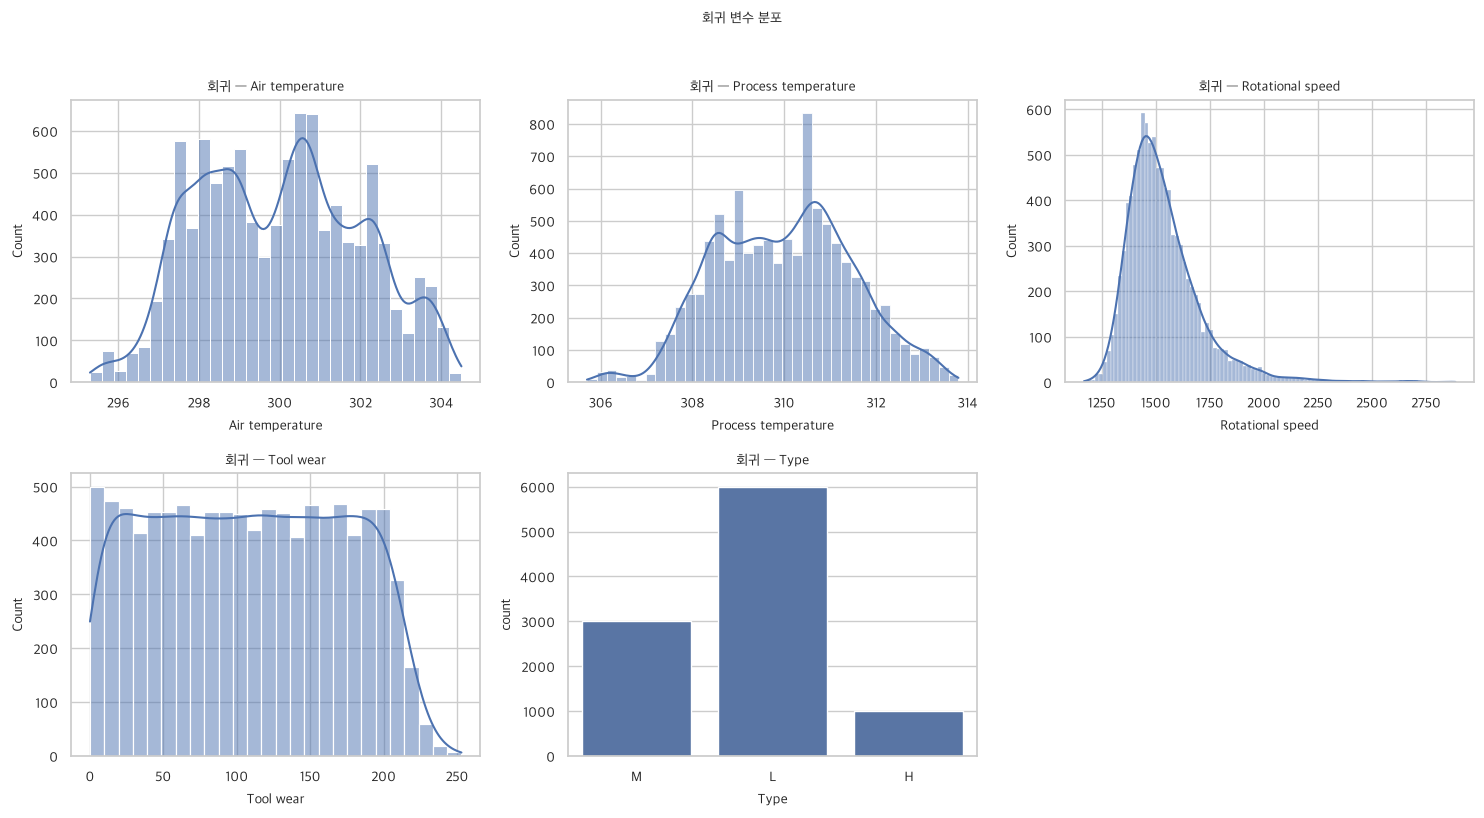

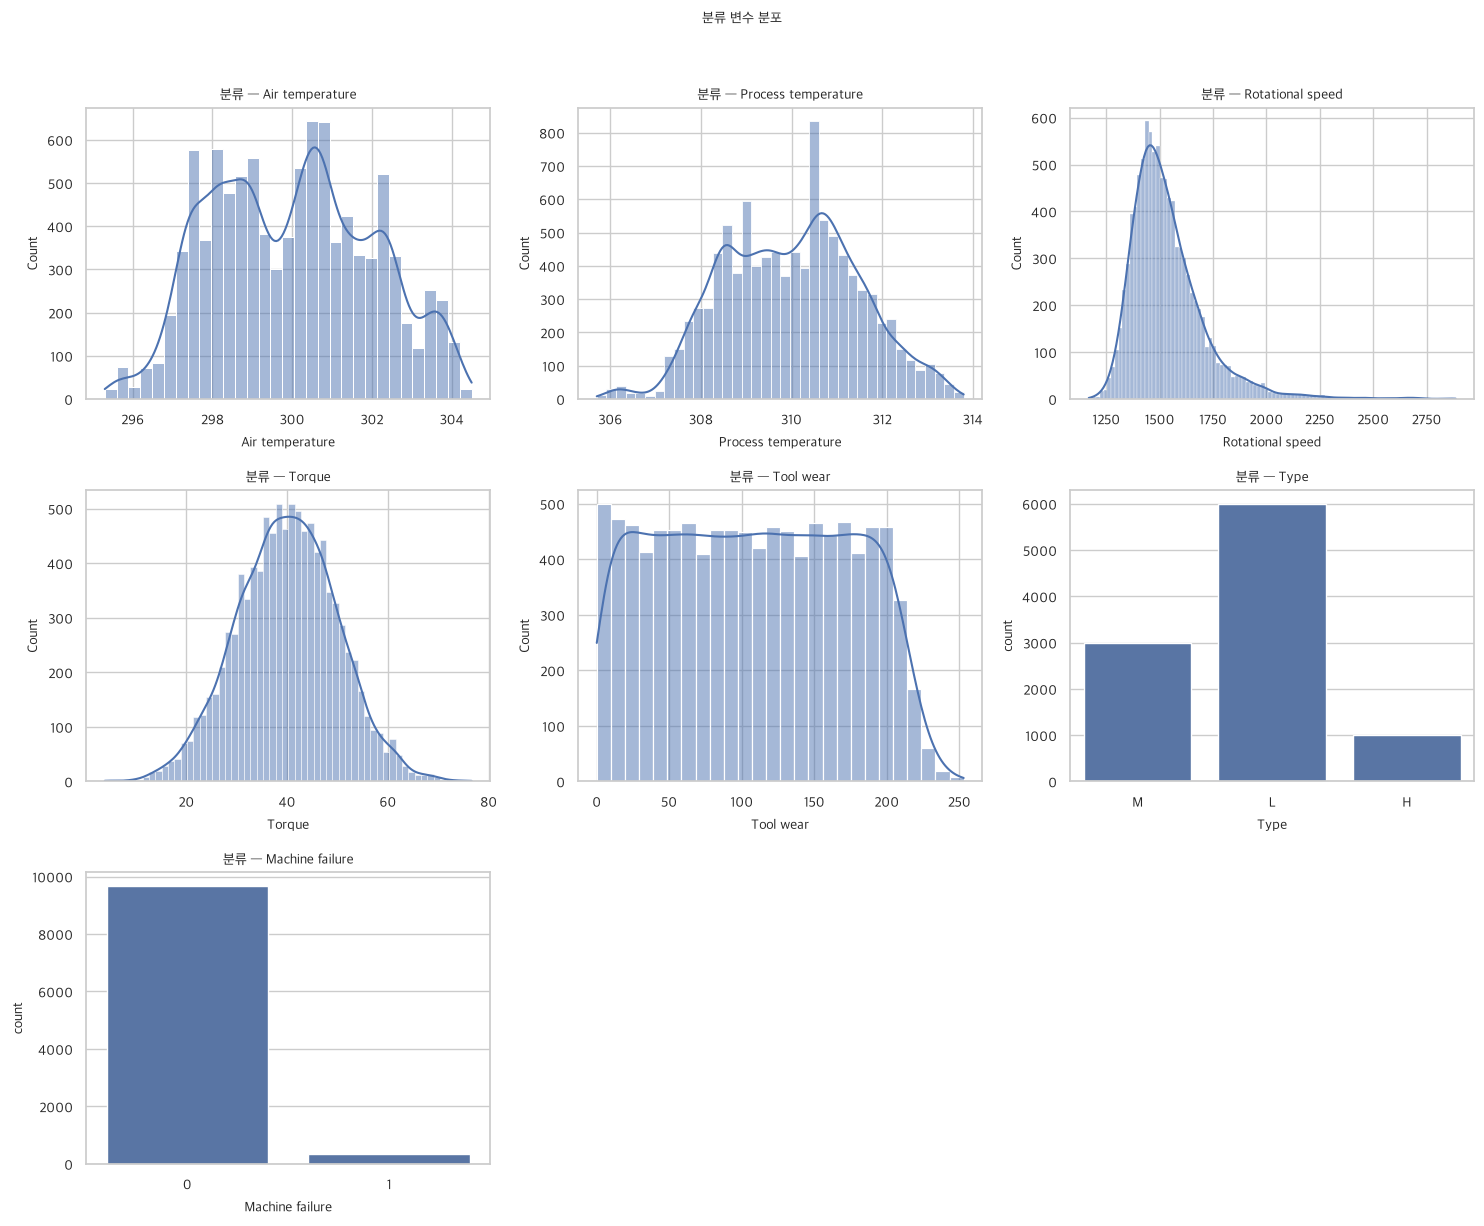

In [7]:
def plot_distributions(df, columns, title_prefix, fig_title):
    """변수 개수에 맞게 subplot 그리드를 자동 생성"""
    configure_plot_korean()
    ncols = 3
    nrows = int(np.ceil(len(columns) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes = np.array(axes).reshape(-1)

    for ax, col in zip(axes, columns):
        if col == "Type" or df[col].nunique() <= 5:
            sns.countplot(data=df, x=col, ax=ax)
        else:
            sns.histplot(df[col], kde=True, ax=ax)
        ax.set_title(f"{title_prefix} — {col}", fontproperties=KOREAN_FONT_PROP)

    for ax in axes[len(columns):]:
        ax.axis("off")

    fig.suptitle(fig_title, y=1.02, fontproperties=KOREAN_FONT_PROP)
    finalize_korean_plot(fig)
    plt.tight_layout()
    plt.show()


reg_plot_cols = list(
    df_reg.select_dtypes(include="number").columns.drop(REG_TARGET, errors="ignore")
) + ["Type"]

cla_plot_cols = [
    c for c in df_cla.select_dtypes(include="number").columns if c != CLA_TARGET
] + ["Type", CLA_TARGET]

plot_distributions(df_reg, reg_plot_cols, "회귀", "회귀 변수 분포")
plot_distributions(df_cla, cla_plot_cols, "분류", "분류 변수 분포")


## 2) 데이터 전처리


### 2-1) 전처리 함수 정의

처리 순서: 범주형 인코딩 → 다중공선성 제거(|corr| ≥ 0.95) → train/test 분할 → StandardScaler


In [8]:
def one_hot_encode(df, cat_col="Type"):
    return pd.get_dummies(df, columns=[cat_col], prefix=cat_col, dtype=int)


def drop_multicollinear(X, y, threshold=0.95):
    work = X.select_dtypes(include="number").copy()
    removed = []
    while work.shape[1] >= 2:
        corr = work.corr().abs()
        upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        pairs = [
            (i, j, upper.loc[i, j])
            for i in upper.index
            for j in upper.columns
            if pd.notna(upper.loc[i, j]) and upper.loc[i, j] >= threshold
        ]
        if not pairs:
            break
        a, b, _ = max(pairs, key=lambda x: x[2])
        corr_a = abs(work[a].corr(y)) if work[a].notna().any() else 0
        corr_b = abs(work[b].corr(y)) if work[b].notna().any() else 0
        drop_col = a if corr_a < corr_b else b
        removed.append(drop_col)
        work = work.drop(columns=[drop_col])
    return X.drop(columns=removed), removed


def max_abs_corr(X):
    num = X.select_dtypes(include="number")
    if num.shape[1] < 2:
        return 0.0
    corr = num.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    return upper.max().max()


def plot_corr_heatmap(X, title, threshold=0.95):
    configure_plot_korean()
    num = X.select_dtypes(include="number")
    if num.shape[1] < 2:
        print(f"{title}: 수치형 변수가 1개 이하여서 heatmap 생략")
        return
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(num.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
    max_corr = max_abs_corr(X)
    status = "multicollinearity-free" if max_corr < threshold else "높은 상관 존재"
    ax.set_title(
        f"{title}\n최대 |corr| = {max_corr:.3f} | {status}",
        fontproperties=KOREAN_FONT_PROP,
    )
    finalize_korean_plot(fig)
    plt.tight_layout()
    plt.show()


def preprocess_task(df, target_col, task_name, stratify=False):
    y = df[target_col].copy()
    X = df.drop(columns=[target_col]).copy()
    X_encoded = one_hot_encode(X)

    X_mc, removed = drop_multicollinear(X_encoded, y, threshold=CORR_THRESHOLD)
    print(f"[{task_name}] 다중공선성 제거: {removed if removed else '없음'}")

    split_kw = dict(test_size=TEST_SIZE, random_state=RANDOM_STATE)
    if stratify:
        split_kw["stratify"] = y
    X_train, X_test, y_train, y_test = train_test_split(X_mc, y, **split_kw)

    num_cols = X_train.select_dtypes(include="number").columns
    scaler = StandardScaler()
    X_train_scaled = X_train.copy()
    X_test_scaled = X_test.copy()
    X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
    X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

    return {
        "task": task_name,
        "X_train": X_train_scaled,
        "X_test": X_test_scaled,
        "y_train": y_train,
        "y_test": y_test,
        "removed_cols": removed,
        "scaler": scaler,
        "feature_names": X_train_scaled.columns.tolist(),
    }


### 2-2) 회귀 / 분류 전처리 실행


In [9]:
reg_data = preprocess_task(df_reg, REG_TARGET, "회귀", stratify=False)
cla_data = preprocess_task(df_cla, CLA_TARGET, "분류", stratify=True)

print("\n회귀 train:", reg_data["X_train"].shape, "| test:", reg_data["X_test"].shape)
print("분류 train:", cla_data["X_train"].shape, "| test:", cla_data["X_test"].shape)


[회귀] 다중공선성 제거: 없음
[분류] 다중공선성 제거: 없음

회귀 train: (7000, 7) | test: (3000, 7)
분류 train: (7000, 8) | test: (3000, 8)


### 2-3) 최종 전처리 후 상관행렬 Heatmap (다중공선성 확인)


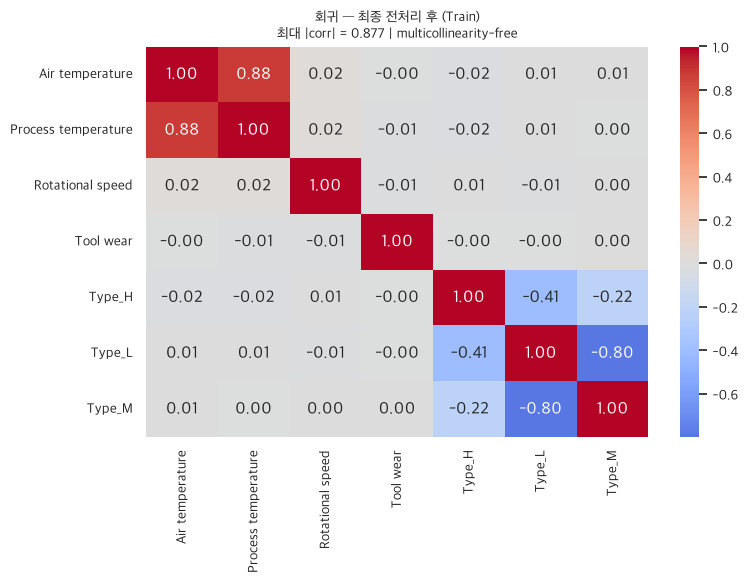

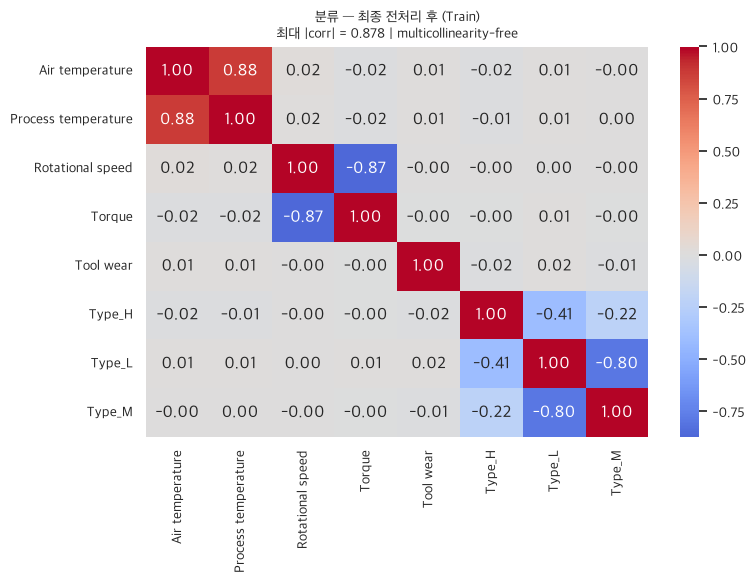

In [10]:
plot_corr_heatmap(reg_data["X_train"], "회귀 — 최종 전처리 후 (Train)", CORR_THRESHOLD)
plot_corr_heatmap(cla_data["X_train"], "분류 — 최종 전처리 후 (Train)", CORR_THRESHOLD)


## 3) 모델링 — 후보 모델 정의


In [11]:
reg_models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "DecisionTree": DecisionTreeRegressor(random_state=RANDOM_STATE),
    "RandomForest": RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    "GBM": GradientBoostingRegressor(random_state=RANDOM_STATE),
    "XGBoost": XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1, verbosity=0),
    "LightGBM": LGBMRegressor(random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
    "CatBoost": CatBoostRegressor(random_state=RANDOM_STATE, verbose=0),
}

_pos_weight = (df_cla[CLA_TARGET] == 0).sum() / (df_cla[CLA_TARGET] == 1).sum()


class BalancedGBMClassifier(GradientBoostingClassifier):
    """GBM은 class_weight 미지원 → fit 시 balanced sample_weight 적용"""

    def fit(self, X, y, sample_weight=None, **kwargs):
        sw = compute_sample_weight(class_weight="balanced", y=y)
        return super().fit(X, y, sample_weight=sw, **kwargs)


cla_models = {
    "Logistic": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "DecisionTree": DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight="balanced"),
    "RandomForest": RandomForestClassifier(random_state=RANDOM_STATE, class_weight="balanced", n_jobs=-1),
    "GBM": BalancedGBMClassifier(random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(random_state=RANDOM_STATE, n_jobs=-1, verbosity=0, scale_pos_weight=_pos_weight),
    "LightGBM": LGBMClassifier(random_state=RANDOM_STATE, n_jobs=-1, verbose=-1, class_weight="balanced"),
    "CatBoost": CatBoostClassifier(random_state=RANDOM_STATE, verbose=0, auto_class_weights="Balanced"),
}

print("회귀 후보:", list(reg_models.keys()))
print("분류 후보:", list(cla_models.keys()))


회귀 후보: ['LinearRegression', 'Ridge', 'Lasso', 'DecisionTree', 'RandomForest', 'GBM', 'XGBoost', 'LightGBM', 'CatBoost']
분류 후보: ['Logistic', 'DecisionTree', 'RandomForest', 'GBM', 'XGBoost', 'LightGBM', 'CatBoost']


## 4) 교차검증 Fold 수 비교 & 최적 모델 선정

- CV fold: 3, 5, 10 각각 시도
- 회귀 지표: neg_mean_absolute_error (MAE 최소화)
- 분류 지표: f1 (불균형 데이터)


In [12]:
def find_best_cv_and_model(X_train, y_train, models, scoring, task_name):
    results = []
    for n_folds in CV_FOLDS:
        for name, model in models.items():
            scores = cross_val_score(
                model, X_train, y_train,
                cv=n_folds, scoring=scoring, n_jobs=-1,
            )
            results.append({
                "task": task_name,
                "model": name,
                "cv_folds": n_folds,
                "mean_score": scores.mean(),
                "std_score": scores.std(),
            })

    result_df = pd.DataFrame(results).sort_values("mean_score", ascending=False)
    best_row = result_df.iloc[0]
    best_model_name = best_row["model"]
    best_cv = int(best_row["cv_folds"])
    print(
        f"\n[{task_name}] 최적 조합 → 모델: {best_model_name}, "
        f"CV folds: {best_cv}, score: {best_row['mean_score']:.4f}"
    )
    return result_df, best_model_name, best_cv, models[best_model_name]


reg_cv_df, best_reg_name, best_reg_cv, best_reg_model = find_best_cv_and_model(
    reg_data["X_train"], reg_data["y_train"], reg_models,
    scoring="neg_mean_absolute_error", task_name="회귀",
)
cla_cv_df, best_cla_name, best_cla_cv, best_cla_model = find_best_cv_and_model(
    cla_data["X_train"], cla_data["y_train"], cla_models,
    scoring="f1", task_name="분류",
)

display(reg_cv_df.head(10))
display(cla_cv_df.head(10))



[회귀] 최적 조합 → 모델: GBM, CV folds: 10, score: -2.9545

[분류] 최적 조합 → 모델: XGBoost, CV folds: 5, score: 0.7419


,task,model,cv_folds,mean_score,std_score
23,회귀,GBM,10,-2.954498,0.092509
14,회귀,GBM,5,-2.956392,0.067425
5,회귀,GBM,3,-2.968890,0.030276
17,회귀,CatBoost,5,-3.030023,0.066240
26,회귀,CatBoost,10,-3.033787,0.075012
25,회귀,LightGBM,10,-3.035864,0.081451
16,회귀,LightGBM,5,-3.036443,0.062060
8,회귀,CatBoost,3,-3.049859,0.033426
7,회귀,LightGBM,3,-3.051512,0.021830
13,회귀,RandomForest,5,-3.117767,0.062586


,task,model,cv_folds,mean_score,std_score
11,분류,XGBoost,5,0.741940,0.022943
4,분류,XGBoost,3,0.730842,0.022987
19,분류,LightGBM,10,0.725343,0.087949
18,분류,XGBoost,10,0.724147,0.071176
5,분류,LightGBM,3,0.703156,0.012959
12,분류,LightGBM,5,0.701801,0.045510
20,분류,CatBoost,10,0.698722,0.067012
13,분류,CatBoost,5,0.690136,0.025987
6,분류,CatBoost,3,0.678011,0.013070
16,분류,RandomForest,10,0.669387,0.054924


## 5) 하이퍼파라미터 튜닝 (RandomizedSearchCV)


In [13]:
REG_PARAM_DIST = {
    "RandomForest": {"n_estimators": [100, 200, 300], "max_depth": [None, 5, 10, 20], "min_samples_split": [2, 5, 10]},
    "XGBoost": {"n_estimators": [100, 200, 300], "max_depth": [3, 5, 7], "learning_rate": [0.01, 0.05, 0.1]},
    "LightGBM": {"n_estimators": [100, 200, 300], "max_depth": [3, 5, 7, -1], "learning_rate": [0.01, 0.05, 0.1]},
    "CatBoost": {"iterations": [100, 200, 300], "depth": [4, 6, 8], "learning_rate": [0.01, 0.05, 0.1]},
    "GBM": {"n_estimators": [100, 200], "max_depth": [3, 5, 7], "learning_rate": [0.01, 0.05, 0.1]},
    "Ridge": {"alpha": [0.01, 0.1, 1, 10, 100]},
    "Lasso": {"alpha": [0.001, 0.01, 0.1, 1]},
    "DecisionTree": {"max_depth": [None, 5, 10, 20], "min_samples_split": [2, 5, 10]},
}

CLA_PARAM_DIST = {
    "RandomForest": {"n_estimators": [100, 200, 300], "max_depth": [None, 5, 10, 20], "min_samples_split": [2, 5, 10]},
    "XGBoost": {"n_estimators": [100, 200, 300], "max_depth": [3, 5, 7], "learning_rate": [0.01, 0.05, 0.1]},
    "LightGBM": {"n_estimators": [100, 200, 300], "max_depth": [3, 5, 7, -1], "learning_rate": [0.01, 0.05, 0.1]},
    "CatBoost": {"iterations": [100, 200, 300], "depth": [4, 6, 8], "learning_rate": [0.01, 0.05, 0.1]},
    "GBM": {"n_estimators": [100, 200], "max_depth": [3, 5, 7], "learning_rate": [0.01, 0.05, 0.1]},
    "Logistic": {"C": [0.01, 0.1, 1, 10], "solver": ["lbfgs", "liblinear"]},
    "DecisionTree": {"max_depth": [None, 5, 10, 20], "min_samples_split": [2, 5, 10]},
}


def tune_model(model, param_dist, X_train, y_train, cv_folds, scoring, n_iter=20):
    if not param_dist:
        model.fit(X_train, y_train)
        return model, {}
    search = RandomizedSearchCV(
        model, param_dist, n_iter=n_iter, cv=cv_folds,
        scoring=scoring, random_state=RANDOM_STATE, n_jobs=-1,
    )
    search.fit(X_train, y_train)
    print(f"  Best params: {search.best_params_}")
    print(f"  Best CV score: {search.best_score_:.4f}")
    return search.best_estimator_, search.best_params_


print(f"[회귀] {best_reg_name} 튜닝 (CV={best_reg_cv})...")
final_reg_model, reg_best_params = tune_model(
    reg_models[best_reg_name],
    REG_PARAM_DIST.get(best_reg_name, {}),
    reg_data["X_train"], reg_data["y_train"],
    cv_folds=best_reg_cv, scoring="neg_mean_absolute_error",
)

print(f"\n[분류] {best_cla_name} 튜닝 (CV={best_cla_cv})...")
final_cla_model, cla_best_params = tune_model(
    cla_models[best_cla_name],
    CLA_PARAM_DIST.get(best_cla_name, {}),
    cla_data["X_train"], cla_data["y_train"],
    cv_folds=best_cla_cv, scoring="f1",
)


[회귀] GBM 튜닝 (CV=10)...
  Best params: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05}
  Best CV score: -2.9481

[분류] XGBoost 튜닝 (CV=5)...
  Best params: {'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.1}
  Best CV score: 0.7399


## 6) Test Set 최종 성능 평가


[회귀] 최종 모델: GBM | CV folds: 10


,지표,값
0,MAE,2.9476
1,MSE,15.6829
2,RMSE,3.9602
3,MAPE (%),7.2361
4,R²,0.8383


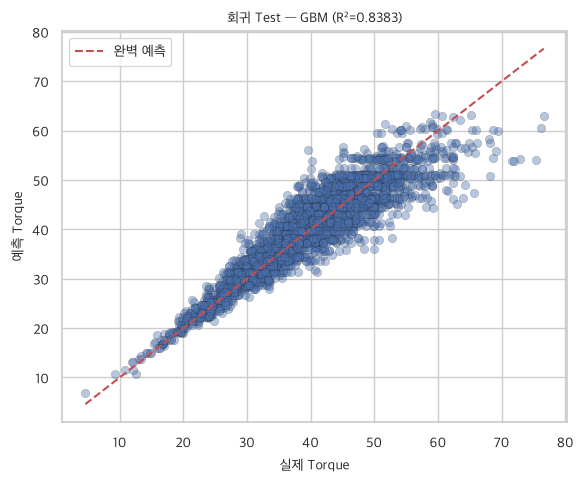

In [14]:
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


y_reg_pred = final_reg_model.predict(reg_data["X_test"])
reg_mae = mean_absolute_error(reg_data["y_test"], y_reg_pred)
reg_mse = mean_squared_error(reg_data["y_test"], y_reg_pred)
reg_rmse = np.sqrt(reg_mse)
reg_mape = mape(reg_data["y_test"], y_reg_pred)
reg_r2 = r2_score(reg_data["y_test"], y_reg_pred)

reg_results = pd.DataFrame({
    "지표": ["MAE", "MSE", "RMSE", "MAPE (%)", "R²"],
    "값": [reg_mae, reg_mse, reg_rmse, reg_mape, reg_r2],
})
reg_results["값"] = reg_results["값"].round(4)

print("=" * 50)
print(f"[회귀] 최종 모델: {best_reg_name} | CV folds: {best_reg_cv}")
print("=" * 50)
display(reg_results)

configure_plot_korean()
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(reg_data["y_test"], y_reg_pred, alpha=0.4, edgecolors="k", linewidth=0.3)
lims = [min(reg_data["y_test"].min(), y_reg_pred.min()), max(reg_data["y_test"].max(), y_reg_pred.max())]
ax.plot(lims, lims, "r--", label="완벽 예측")
ax.set_xlabel("실제 Torque", fontproperties=KOREAN_FONT_PROP)
ax.set_ylabel("예측 Torque", fontproperties=KOREAN_FONT_PROP)
ax.set_title(f"회귀 Test — {best_reg_name} (R²={reg_r2:.4f})", fontproperties=KOREAN_FONT_PROP)
ax.legend(prop=KOREAN_FONT_PROP)
finalize_korean_plot(fig)
plt.tight_layout()
plt.show()


[분류] 최종 모델: XGBoost | CV folds: 5


,지표,값
0,Accuracy,0.9823
1,Precision,0.7426
2,Recall,0.7353
3,F1,0.7389
4,AUC,0.9785


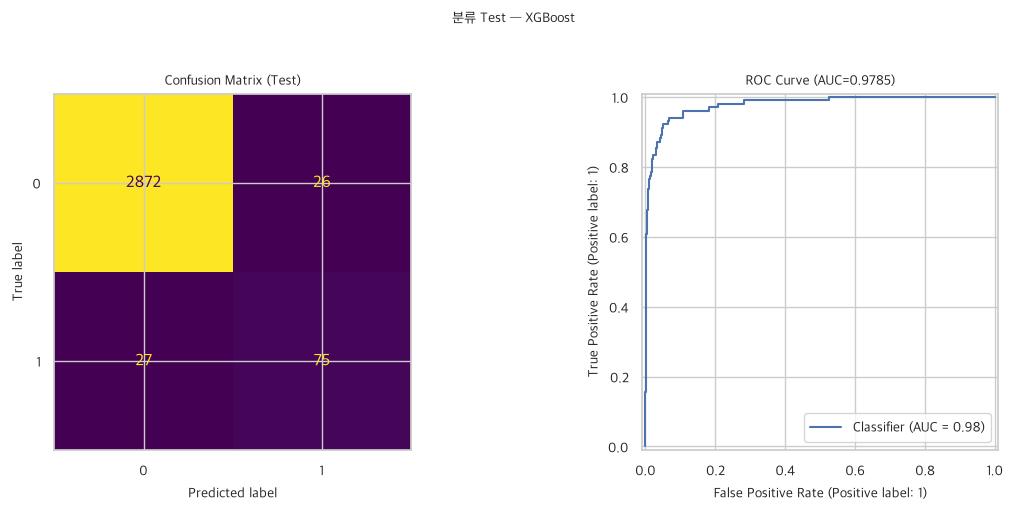

In [15]:
y_cla_pred = final_cla_model.predict(cla_data["X_test"])
y_cla_proba = (
    final_cla_model.predict_proba(cla_data["X_test"])[:, 1]
    if hasattr(final_cla_model, "predict_proba")
    else None
)

cla_acc = accuracy_score(cla_data["y_test"], y_cla_pred)
cla_prec = precision_score(cla_data["y_test"], y_cla_pred, zero_division=0)
cla_rec = recall_score(cla_data["y_test"], y_cla_pred, zero_division=0)
cla_f1 = f1_score(cla_data["y_test"], y_cla_pred, zero_division=0)
cla_auc = roc_auc_score(cla_data["y_test"], y_cla_proba) if y_cla_proba is not None else np.nan

cla_results = pd.DataFrame({
    "지표": ["Accuracy", "Precision", "Recall", "F1", "AUC"],
    "값": [cla_acc, cla_prec, cla_rec, cla_f1, cla_auc],
})
cla_results["값"] = cla_results["값"].round(4)

print("=" * 50)
print(f"[분류] 최종 모델: {best_cla_name} | CV folds: {best_cla_cv}")
print("=" * 50)
display(cla_results)

configure_plot_korean()
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(
    cla_data["y_test"], y_cla_pred, ax=axes[0], colorbar=False,
)
axes[0].set_title("Confusion Matrix (Test)", fontproperties=KOREAN_FONT_PROP)

if y_cla_proba is not None:
    RocCurveDisplay.from_predictions(cla_data["y_test"], y_cla_proba, ax=axes[1])
    axes[1].set_title(f"ROC Curve (AUC={cla_auc:.4f})", fontproperties=KOREAN_FONT_PROP)
else:
    axes[1].axis("off")

fig.suptitle(f"분류 Test — {best_cla_name}", y=1.02, fontproperties=KOREAN_FONT_PROP)
finalize_korean_plot(fig)
plt.tight_layout()
plt.show()


## 7) 최종 요약


In [16]:
summary = pd.DataFrame([
    {
        "태스크": "회귀 (Torque)",
        "최적 모델": best_reg_name,
        "CV folds": best_reg_cv,
        "Test MAE": round(reg_mae, 4),
        "Test RMSE": round(reg_rmse, 4),
        "Test R²": round(reg_r2, 4),
    },
    {
        "태스크": "분류 (Machine failure)",
        "최적 모델": best_cla_name,
        "CV folds": best_cla_cv,
        "Test F1": round(cla_f1, 4),
        "Test Recall": round(cla_rec, 4),
        "Test AUC": round(cla_auc, 4) if not np.isnan(cla_auc) else "-",
    },
])
display(summary)


,태스크,최적 모델,CV folds,Test MAE,Test RMSE,Test R²,Test F1,Test Recall,Test AUC
0,회귀 (Torque),GBM,10,2.9476,3.9602,0.8383,NaN,NaN,NaN
1,분류 (Machine failure),XGBoost,5,NaN,NaN,NaN,0.7389,0.7353,0.9785


## 8) 변수 중요도 (최종 모델)


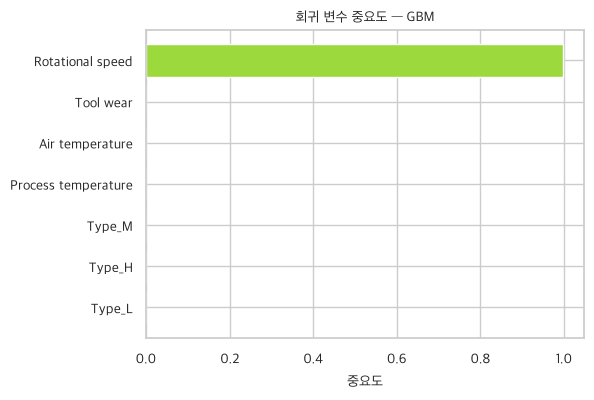

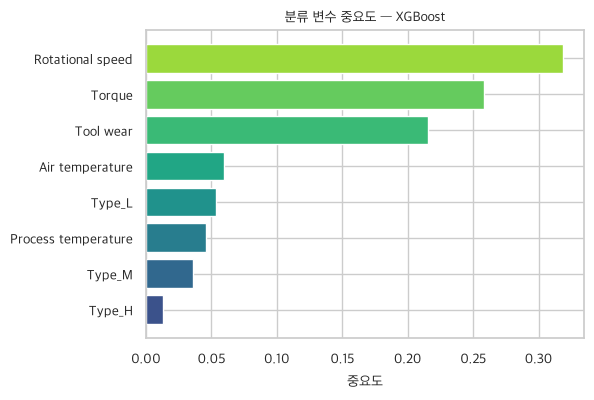

In [19]:
def plot_feature_importance(model, feature_names, title, top_n=15):
    if hasattr(model, "feature_importances_"):
        imp = model.feature_importances_
    elif hasattr(model, "coef_"):
        imp = np.abs(model.coef_).ravel()
    else:
        print(f"{title}: 변수 중요도를 지원하지 않는 모델입니다.")
        return

    configure_plot_korean()
    fi = pd.Series(imp, index=feature_names).sort_values(ascending=True).tail(top_n)

    fig_h = max(4, 0.5 * len(fi))
    fig, ax = plt.subplots(figsize=(10, fig_h))

    colors = plt.cm.viridis(np.linspace(0.25, 0.85, len(fi)))
    ax.barh(fi.index, fi.values, color=colors)

    ax.set_title(title, fontproperties=KOREAN_FONT_PROP)
    ax.set_xlabel("중요도", fontproperties=KOREAN_FONT_PROP)

    # y축 눈금 = 변수명 (별도 ylabel 없음)
    ax.set_yticklabels(fi.index, fontproperties=KOREAN_FONT_PROP)
    ax.tick_params(axis="y", labelsize=10)

    # 긴 변수명이 잘리지 않도록 왼쪽 여백 자동 조정
    max_label_len = max(len(str(name)) for name in fi.index)
    left_margin = min(0.55, 0.12 + max_label_len * 0.018)
    fig.subplots_adjust(left=left_margin)
    finalize_korean_plot(fig)
    plt.show()


plot_feature_importance(
    final_reg_model, reg_data["feature_names"],
    f"회귀 변수 중요도 — {best_reg_name}",
)
plot_feature_importance(
    final_cla_model, cla_data["feature_names"],
    f"분류 변수 중요도 — {best_cla_name}",
)
